**Muhammad Zaid Maqsood**
- NYC_Housing_Market
---
**Instructions**
- Create a folder in your google drive with name **Python**
- Upload Python_Project_Dataset.zip in **Python** folder
- Open CISC-5380_NYC_Housing_Market.ipynb in google colab
- Run all and provide access to your google drive
- Code will automatically extract zip file and create a new folder with all dataset csv's.
- *Primary Variables*: Price, PropertySQFT, BEDS, BATH, Property LAT/LONG, Subway LAT/LONG and Crime Incident LAT/LONG

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels.api as sm
import seaborn as sns
import re
import statsmodels.formula.api as smf
from scipy.spatial import cKDTree
from scipy.stats import ttest_ind
from matplotlib.colors import LinearSegmentedColormap
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from geopy.distance import geodesic
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import randint, uniform
from scipy.stats import ttest_ind
from sklearn.neighbors import BallTree
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

**Connecting google drive with colab and Unzip Dataset Zip file****

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import zipfile
zip_file_path = '/content/drive/MyDrive/Python/Python_Project_Dataset.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Python/Python_Project_Dataset')


Mounted at /content/drive


**Accessing the datasets**

In [ ]:
ny_housing_raw=pd.read_csv("/content/drive/MyDrive/Python/Python_Project_Dataset/NY-House-Dataset.csv")
subway_raw = pd.read_csv("/content/drive/MyDrive/Python/Python_Project_Dataset/MTA_Subway_Stations.csv")
crime_raw = pd.read_csv("/content/drive/MyDrive/Python/Python_Project_Dataset/NYPD_Crime_2025.csv")



---



**Preprocessing Stage**

In [ ]:
# ------------------------------------------------------------------
# Preparing dataset for use
# ------------------------------------------------------------------
ny_housing_raw.columns = ny_housing_raw.columns.str.strip().str.upper().str.replace(' ', '', regex=False)
ny_housing_raw = ny_housing_raw.rename(columns={'FORMATTED_ADDRESS': 'PROPERTY'})
ny_housing_raw['TYPE'] = ny_housing_raw['TYPE'].str.replace(' for sale', '', regex=False).str.strip()

subway_raw.columns = subway_raw.columns.str.upper().str.strip()
subway_raw = subway_raw.rename(columns={'STATION ID': 'STATION_ID'})
subway_raw = subway_raw.rename(columns={'GTFS LATITUDE': 'GTFS_LATITUDE'})
subway_raw = subway_raw.rename(columns={'GTFS LONGITUDE': 'GTFS_LONGITUDE'})

crime_raw.columns = crime_raw.columns.str.upper().str.strip()

# Feature Engineering (price/bed, Price per square foot)
# Unit/Apt column
unit_pattern = r'(?:#|APT|UNIT|SUITE|STE)\s*([A-Za-z0-9\- ]+)'
ny_housing_raw['UNIT/APT'] = ny_housing_raw['ADDRESS'].str.extract(unit_pattern, flags=re.IGNORECASE)

# Borough column
borough_map = { 'Bronx County': 'The Bronx', 'The Bronx': 'The Bronx', 'East Bronx': 'The Bronx', 'Riverdale': 'The Bronx',
                'Brooklyn': 'Brooklyn', 'Brooklyn Heights': 'Brooklyn', 'Coney Island': 'Brooklyn', 'Dumbo': 'Brooklyn', 'Fort Hamilton': 'Brooklyn', 'Kings County': 'Brooklyn', 'Snyder Avenue': 'Brooklyn',
                'Queens': 'Queens', 'Queens County': 'Queens', 'Flushing': 'Queens', 'Jackson Heights': 'Queens', 'Rego Park': 'Queens',
                'Manhattan': 'Manhattan', 'New York': 'Manhattan', 'New York County': 'Manhattan',
                'Staten Island': 'Staten Island', 'Richmond County': 'Staten Island' }
ny_housing_raw['BOROUGH'] = ny_housing_raw['SUBLOCALITY'].map(borough_map)

# Create copy of raw dataset
ny_housing = ny_housing_raw[['PROPERTY', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'UNIT/APT', 'BOROUGH', 'LATITUDE', 'LONGITUDE']].copy()
subway = subway_raw[['STATION_ID', 'GTFS_LATITUDE', 'GTFS_LONGITUDE']].copy()
crime = crime_raw[['CMPLNT_NUM', 'LATITUDE', 'LONGITUDE']].copy()

# ------------------------------------------------------------------
# Numeric cleaning: Correct datatype and remove special symbols
# ------------------------------------------------------------------
# ny_housing dataset
num_cols = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']
for c in num_cols:
    cleaned_numeric = (
        ny_housing[c].astype(str).str.replace(',', '', regex=False).str.replace('$', '', regex=False).str.strip()
    )
    # Convert to numbers and output NaN for invalid values
    cleaned_numeric = pd.to_numeric(cleaned_numeric, errors='coerce')
    # Check BEDS and BATH for non-integer and NaN cells
    if c in ['BEDS', 'BATH']:
        ny_housing[c] = cleaned_numeric.round().astype(float)
    else:
        ny_housing[c] = cleaned_numeric

print("For raw data, average property price (million) is: ", round(ny_housing['PRICE'].mean()/100000, 2))
print("For raw data, median property price (million) is: ", round(ny_housing['PRICE'].median()/100000, 2))
print()

# subway stations dataset
subway['GTFS_LATITUDE'] = pd.to_numeric(subway['GTFS_LATITUDE'], errors='coerce')
subway['GTFS_LONGITUDE'] = pd.to_numeric(subway['GTFS_LONGITUDE'], errors='coerce')

# crime dataset
crime['LATITUDE'] = pd.to_numeric(crime['LATITUDE'], errors='coerce')
crime['LONGITUDE'] = pd.to_numeric(crime['LONGITUDE'], errors='coerce')

# ------------------------------------------------------------------
# Remove duplicates, reset index and drop 'UNIT/APT'
# ------------------------------------------------------------------
ny_housing = ny_housing.drop_duplicates(subset=['PROPERTY', 'UNIT/APT', 'PRICE', 'PROPERTYSQFT']).reset_index(drop=True)
ny_housing = ny_housing.drop(columns=['UNIT/APT'])

crime = crime.drop_duplicates(subset=['CMPLNT_NUM']).reset_index(drop=True)

# ------------------------------------------------------------------
# Validate geocoordinates
# ------------------------------------------------------------------
ny_housing = ny_housing[(ny_housing['LATITUDE'].between(40.3, 41.0, inclusive="both")) & (ny_housing['LONGITUDE'].between(-74.3, -73.5, inclusive="both"))]
subway = subway.dropna(subset=['GTFS_LATITUDE', 'GTFS_LONGITUDE'])
crime = crime.dropna(subset=['LATITUDE', 'LONGITUDE'])

# ------------------------------------------------------------------
# Outlier Removal using 5th to 95th Percentiles on PRICE
# ------------------------------------------------------------------
ny_housing = ny_housing[(ny_housing["PRICE"] >= ny_housing["PRICE"].quantile(0.05)) & (ny_housing["PRICE"] <= ny_housing["PRICE"].quantile(0.95))]
ny_housing = ny_housing[ny_housing['TYPE']!='Condop']
ny_housing = ny_housing.reset_index(drop=True)

# ------------------------------------------------------------------
# Summary of Dataset
# ------------------------------------------------------------------
print(ny_housing[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']].describe())
print("\nTotal properties:", len(ny_housing))
print(ny_housing.info())
print(subway.info())
print(crime.info())
print("For cleaned data, average property price (million) is: ", round(ny_housing['PRICE'].mean()/100000, 2))
print("For cleaned data, median property price (million) is: ", round(ny_housing['PRICE'].median()/100000, 2))


For raw data, average property price (million) is:  19.74
For raw data, median property price (million) is:  8.48

              PRICE         BEDS         BATH  PROPERTYSQFT
count  3.763000e+03  3763.000000  3597.000000   3763.000000
mean   1.226462e+06     3.344938     2.299138   2020.372259
std    1.168360e+06     2.557383     1.697191   1636.243273
min    2.250000e+05     1.000000     1.000000    250.000000
25%    5.355000e+05     2.000000     1.000000   1200.000000
50%    8.380000e+05     3.000000     2.000000   2184.210000
75%    1.399000e+06     4.000000     3.000000   2184.210000
max    6.999000e+06    40.000000    32.000000  55300.000000

Total properties: 3763
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3763 entries, 0 to 3762
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PROPERTY      3763 non-null   object 
 1   TYPE          3763 non-null   object 
 2   PRICE         3763 non-null   int64  


In [ ]:
# ------------------------------------------------------------------
# Filling missing values of BATH column using KNN
# ------------------------------------------------------------------

# Training data (rows with bath present)
X = ny_housing.loc[ny_housing['BATH'].notnull(), ['BEDS', 'PROPERTYSQFT']]
y = ny_housing.loc[ny_housing['BATH'].notnull(), 'BATH']
'''#.loc is used to filter rows and cols #.loc(rows condition, columns condition) # condition could be name only or followed by logic'''


# Test data (Rows where bath is missing)
X_miss = ny_housing.loc[ny_housing['BATH'].isnull(), ['BEDS', 'PROPERTYSQFT']]

# Scaling using default z-score standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
X_miss_scaled = scaler.transform(X_miss)

# Fit KNN (only once) using default euclidean distance
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train_scaled, y)

# Predict and fill
ny_housing.loc[ny_housing['BATH'].isnull(), 'BATH'] = knn.predict(X_miss_scaled)
ny_housing['BATH'] = ny_housing['BATH'].round().astype('Int64')

print("Revised rows in BATH: ", ny_housing['BATH'].count())

Revised rows in BATH:  3763


**EDA**

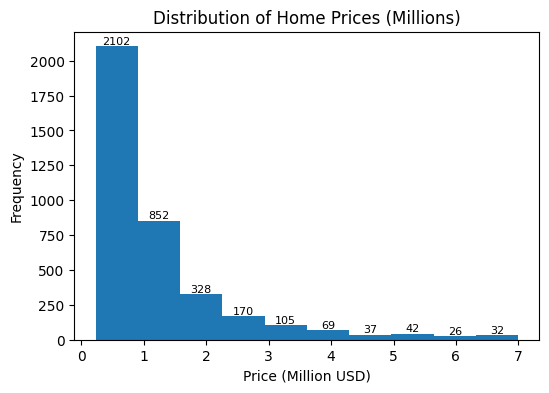

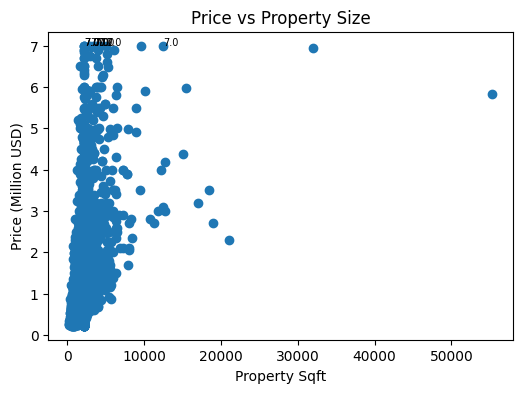

<Figure size 600x400 with 0 Axes>

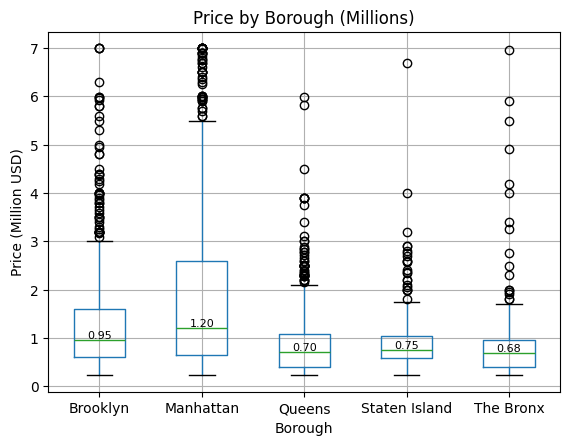

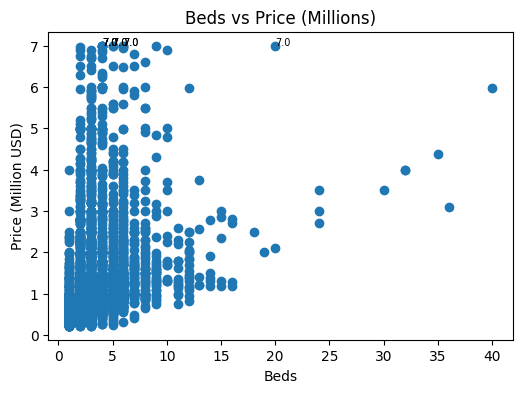

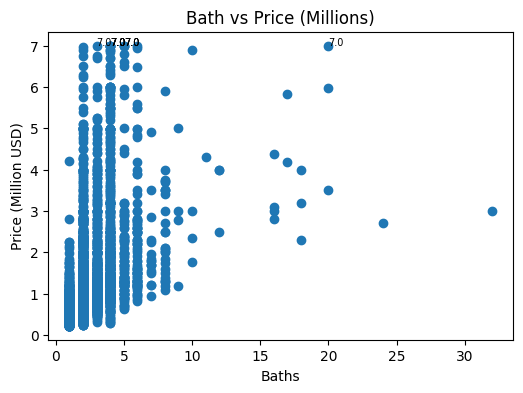

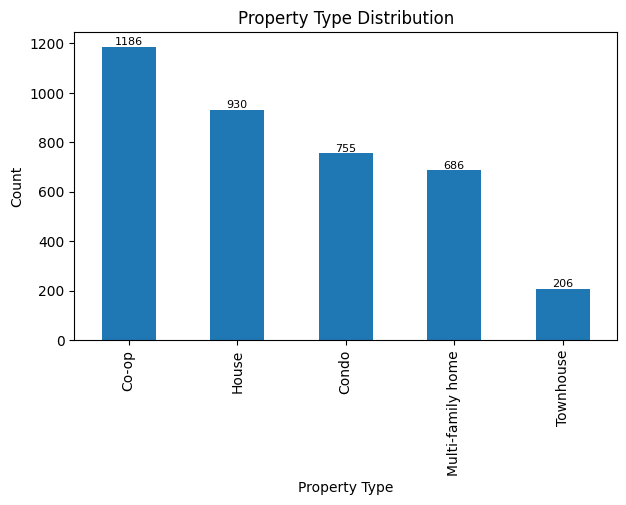

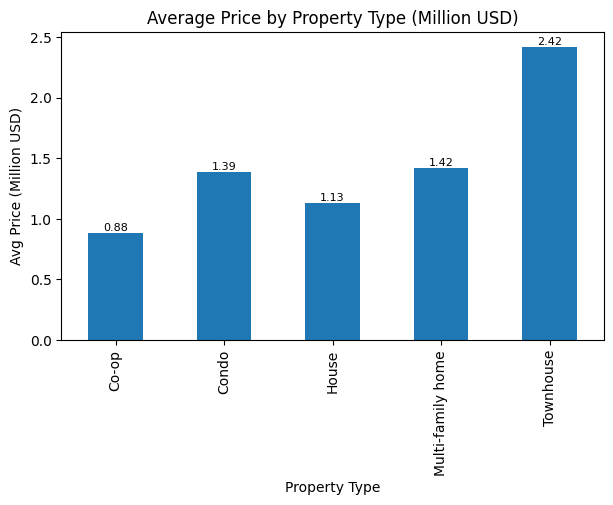

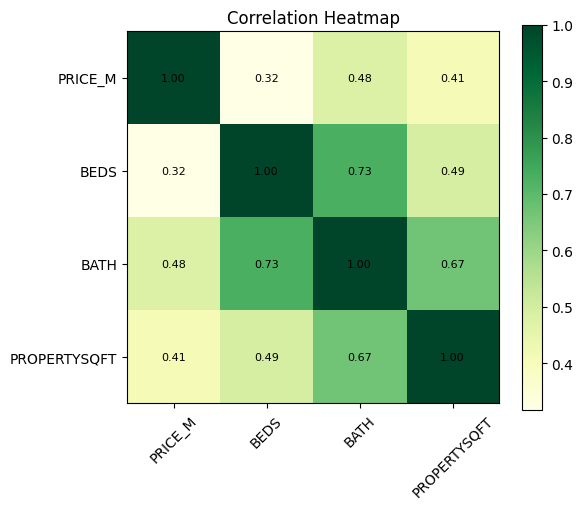

In [ ]:
# Selected one color palette as global colormap
cmap = sns.color_palette("Spectral", as_cmap=True)

# price in million
ny_housing['PRICE_M'] = ny_housing['PRICE'] / 1000000

'''
# fig = the overall canvas/window
# ax (subplots) = individual charts inside the figure
# Matplotlib tracks a "current figure" and a "current axes" internally.
  When plt.figure() is called, a new figure is created and activated, so subsequent plt.* commands automatically apply to that figure.
# Alternatively, fig, ax = plt.subplots(rows, cols) creates a single figure with rows × cols Axes (charts) inside it, which can be accessed via ax[i, j]
  or ax[i] if there is only one column or one row).
# Rows → vertical stacking (top to bottom)
# Columns → horizontal stacking (left to right)
'''
'''
Chart types and Standard template for plotting:
# plt.plot(x,y) | plt.scatter(x,y) | plt.bar(x,h) | plt.barh(y,w) | plt.hist(data,bins) | plt.boxplot(data) | plt.violinplot(data) | plt.pie(vals,labels) |
# plt.stackplot(x,y1,y2) | plt.stem(x,y) | plt.step(x,y) | plt.errorbar(x,y,yerr) | plt.hexbin(x,y) | plt.hist2d(x,y,bins) | plt.imshow(img) | plt.contour(X,Y,Z)

plt.figure()
plt.scatter(x, y)
plt.title("Title")
plt.xlabel("X")
plt.ylabel("Y")
plt.text() # uses data coordinates by default # plt.text( x, y, "Label", fontsize=9, color='black', ha='center', va='bottom', alpha=0.8 )
plt.show()
'''

# Histogram of Price (Millions)
plt.figure(figsize=(6,4))
plt.hist(ny_housing['PRICE_M'].dropna())
plt.title("Distribution of Home Prices (Millions)")
plt.xlabel("Price (Million USD)")
plt.ylabel("Frequency")
ax = plt.gca() # get current axis (chart)
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}", (patch.get_x() + patch.get_width() / 2, height), ha='center', va='bottom', fontsize=8)
plt.show()

# Scatter: Price vs Property Size
plt.figure(figsize=(6,4))
plt.scatter(ny_housing['PROPERTYSQFT'], ny_housing['PRICE_M'])
plt.title("Price vs Property Size")
plt.xlabel("Property Sqft")
plt.ylabel("Price (Million USD)")

top_idx = ny_housing['PRICE_M'].nlargest(10).index
for i in top_idx:
    plt.text(ny_housing['PROPERTYSQFT'][i],ny_housing['PRICE_M'][i],f"{ny_housing['PRICE_M'][i]:.1f}",fontsize=7)
plt.show()

# Boxplot: Median Price by Borough
plt.figure(figsize=(6,4))
ny_housing.boxplot(column='PRICE_M', by='BOROUGH')
plt.title("Price by Borough (Millions)")
plt.suptitle("")
plt.xlabel("Borough")
plt.ylabel("Price (Million USD)")

medians = ny_housing.groupby('BOROUGH')['PRICE_M'].median()
ax = plt.gca()
for idx, (label, median) in enumerate(medians.items()):
    ax.text(idx + 1, median, f"{median:.2f}", ha='center', va='bottom', fontsize=8 )
plt.show()

# Beds vs Price
plt.figure(figsize=(6,4))
plt.scatter(ny_housing['BEDS'], ny_housing['PRICE_M'])
plt.title("Beds vs Price (Millions)")
plt.xlabel("Beds")
plt.ylabel("Price (Million USD)")

top_idx = ny_housing['PRICE_M'].nlargest(10).index
for i in top_idx:
    plt.text(ny_housing['BEDS'][i],ny_housing['PRICE_M'][i],f"{ny_housing['PRICE_M'][i]:.1f}",fontsize=7)
plt.show()

# Bath vs Price
plt.figure(figsize=(6,4))
plt.scatter(ny_housing['BATH'], ny_housing['PRICE_M'])
plt.title("Bath vs Price (Millions)")
plt.xlabel("Baths")
plt.ylabel("Price (Million USD)")

top_idx = ny_housing['PRICE_M'].nlargest(10).index
for i in top_idx:
    plt.text(ny_housing['BATH'][i],ny_housing['PRICE_M'][i],f"{ny_housing['PRICE_M'][i]:.1f}",fontsize=7)
plt.show()

# Property Type Distribution (Bar Chart)
plt.figure(figsize=(7,4))
ny_housing['TYPE'].value_counts().plot(kind='bar')
plt.title("Property Type Distribution")
plt.xlabel("Property Type")
plt.ylabel("Count")

ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=8 )
plt.show()

# Average Price by Property Type
plt.figure(figsize=(7,4))
ny_housing.groupby('TYPE')['PRICE_M'].mean().plot(kind='bar')
plt.title("Average Price by Property Type (Million USD)")
plt.ylabel("Avg Price (Million USD)")
plt.xlabel("Property Type")

# Annotate each bar with average price
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}", (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=8 )
plt.show()

# Correlation Heatmap
corr = ny_housing[['PRICE_M','BEDS','BATH','PROPERTYSQFT']].corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='nearest', cmap='YlGn')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")

# Annotate each heatmap cell with correlation value
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8 )
plt.show()

# Geographic Scatter
fig = px.scatter_mapbox(ny_housing, lat="LATITUDE", lon="LONGITUDE", text="PROPERTY", zoom=10, center={"lat": 40.7128, "lon": -74.0060}, height=600)

fig.update_layout(mapbox_style="open-street-map")
fig.show()


**Research Question 1: How do internal property attributes such as bedrooms, bathrooms, square footage, and home type aﬀect borough-specific property prices?**



Correlation between Attributes and Price by Borough 



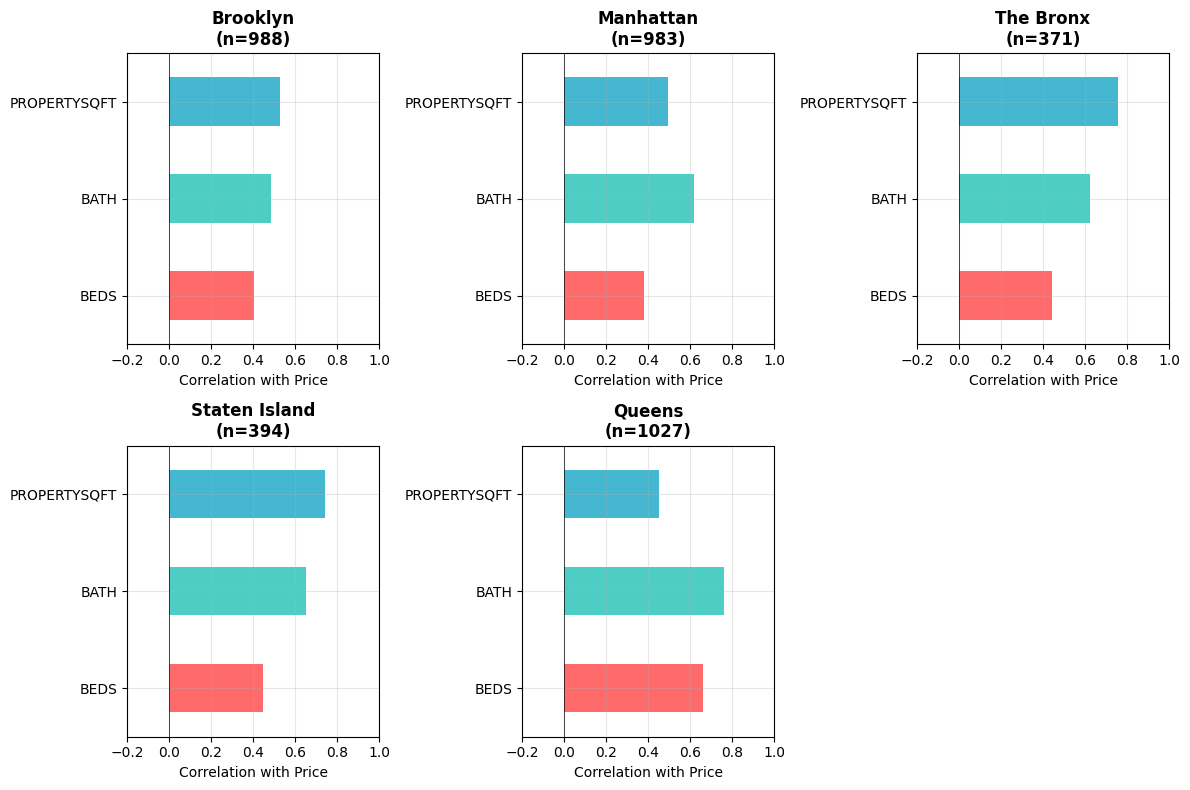


Correlation Summary (with PRICE):
      Borough  BEDS_corr  BATH_corr  SQFT_corr
     Brooklyn   0.402928   0.487811   0.526797
    Manhattan   0.380381   0.620581   0.494356
    The Bronx   0.441826   0.625728   0.755806
Staten Island   0.447652   0.651071   0.743288
       Queens   0.659708   0.762679   0.452574


Property Type affects by Borough 



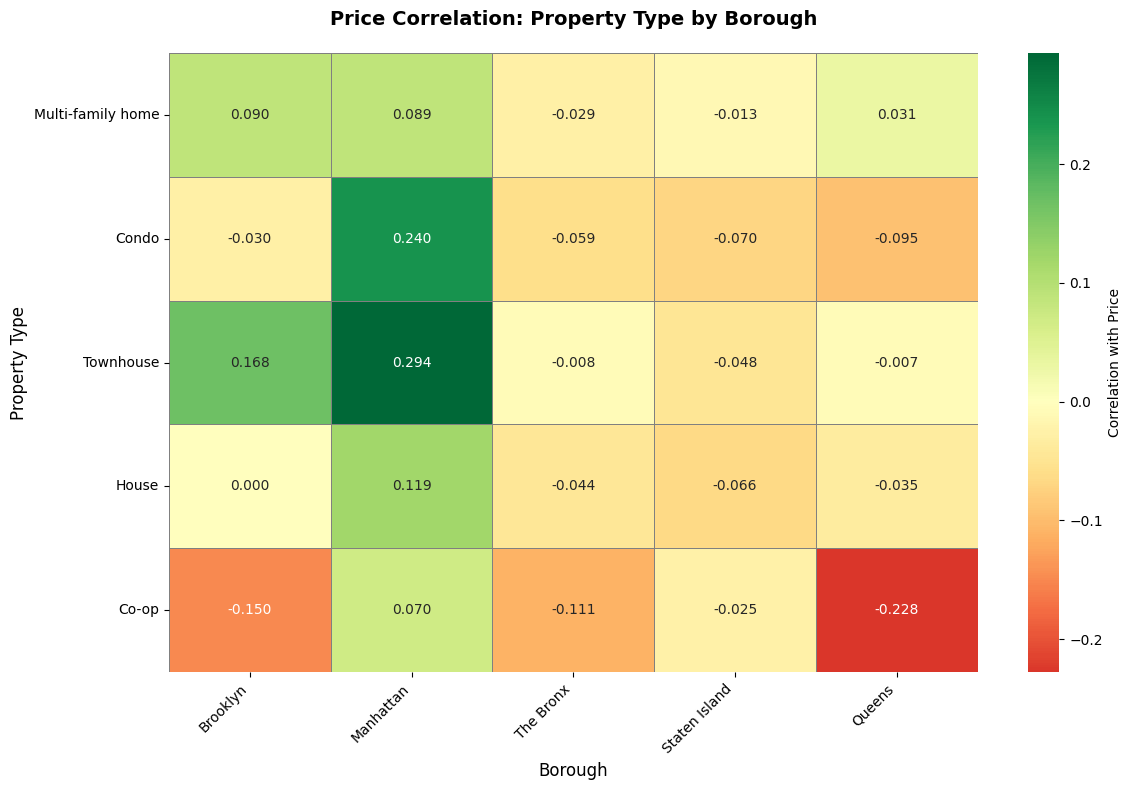


Correlation Matrix (Property Type x Borough with Price):
                   Brooklyn  Manhattan  The Bronx  Staten Island    Queens
Multi-family home  0.089902   0.089210  -0.028752      -0.012961  0.030894
Condo             -0.030109   0.239742  -0.058559      -0.069829 -0.095130
Townhouse          0.167953   0.293954  -0.007987      -0.047607 -0.007196
House              0.000084   0.119207  -0.043904      -0.065799 -0.035443
Co-op             -0.150120   0.069943  -0.110620      -0.024900 -0.228039


Square Footage Impact by Borough 



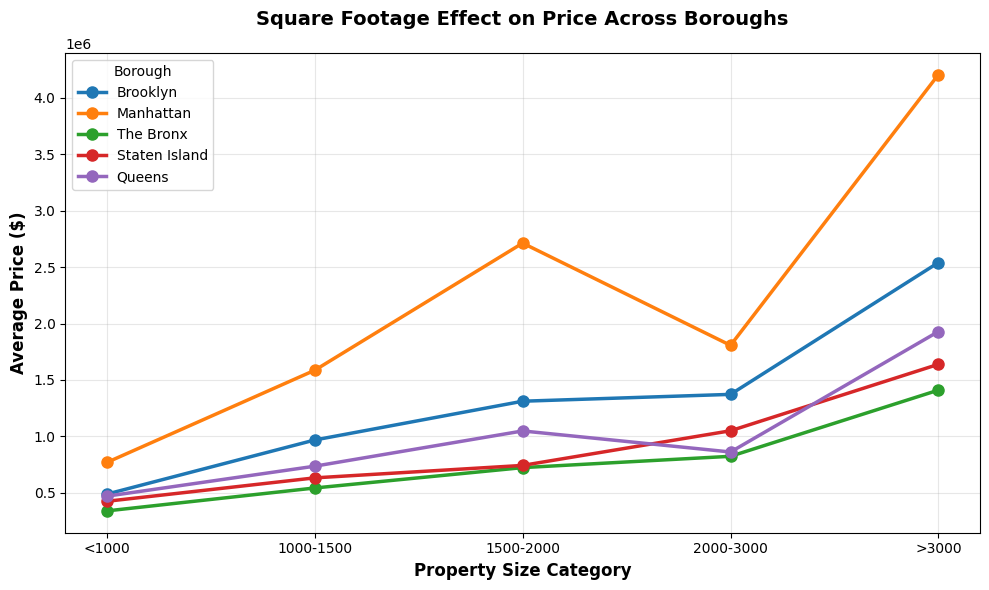



Bathroom Impact Analysis accross Boroughs 



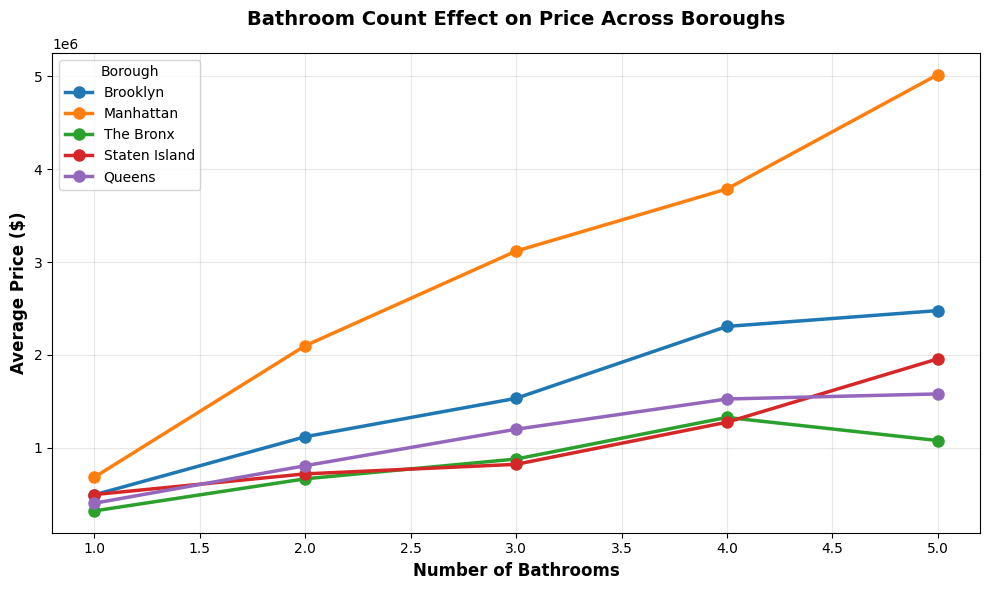



Bedroom Impact Analysis across Boroughs 



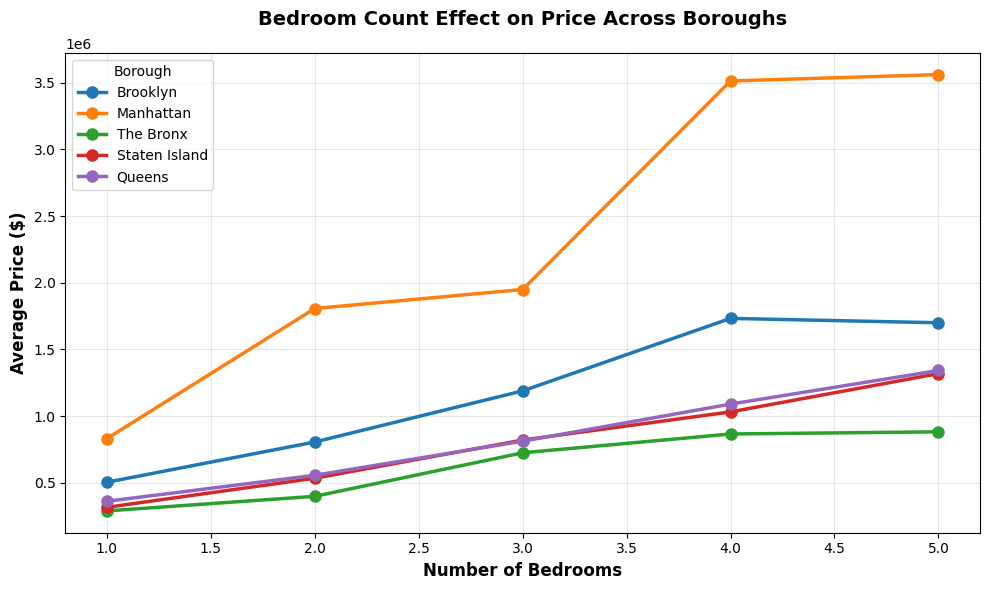

KEY FINDINGS SUMMARY

1. Strongest Correlation with Price by Borough:
      Borough  SQFT_corr
    The Bronx   0.755806
Staten Island   0.743288
     Brooklyn   0.526797
    Manhattan   0.494356
       Queens   0.452574

2. Average Price per Square Foot (Highest to Lowest):
                     mean      median         std
BOROUGH                                          
Manhattan      997.796441  865.301413  694.458865
Brooklyn       660.693035  572.060310  380.123265
Queens         470.276176  427.777778  278.152520
Staten Island  458.072530  436.471298  186.078768
The Bronx      385.757508  350.057176  179.555507

3. Most Expensive Property Type by Borough:
  Brooklyn: Townhouse ($2,479,878)
  Manhattan: Townhouse ($4,046,055)
  The Bronx: Multi-family home ($1,046,008)
  Staten Island: Multi-family home ($1,123,065)
  Queens: Multi-family home ($1,377,598)


In [ ]:
# ----------------------------------------------------------------------------
# RESEARCH QUESTION 1:
# ----------------------------------------------------------------------------

#
ny_housing_rq1 = ny_housing.copy()

# ----------------------------------------------------------------------------
# correlation Analysis by Borough
# ----------------------------------------------------------------------------
print("\n\nCorrelation between Attributes and Price by Borough \n")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

boroughs = ny_housing_rq1['BOROUGH'].unique()
correlation_summary = []

for idx, borough in enumerate(boroughs):
    borough_data = ny_housing_rq1[ny_housing_rq1['BOROUGH'] == borough]

    # Calculate correlations with price
    correlations = borough_data[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']].corr()['PRICE'].drop('PRICE')
    correlation_summary.append({ 'Borough': borough, 'BEDS_corr': correlations['BEDS'], 'BATH_corr': correlations['BATH'], 'SQFT_corr': correlations['PROPERTYSQFT'] })

    # Visualize correlations
    correlations.plot(kind='barh', ax=axes[idx], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[idx].set_title(f'{borough}\n(n={len(borough_data)})', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Correlation with Price')
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[idx].set_xlim(-0.2, 1.0)
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplot if needed
if len(boroughs) < 6:
    axes[5].axis('off')

plt.tight_layout()
plt.show()

# Print correlation summary
corr_df = pd.DataFrame(correlation_summary)
print("\nCorrelation Summary (with PRICE):")
print(corr_df.to_string(index=False))

# ----------------------------------------------------------------------------
# Property Type affects by Borough (Correlation Heatmap)
# ----------------------------------------------------------------------------
print("\n\nProperty Type affects by Borough \n")

# Create combined type-borough feature
ny_housing_rq1['TYPE_BOROUGH'] = ny_housing_rq1['TYPE'] + ' - ' + ny_housing_rq1['BOROUGH']

# One-hot encode the combined feature
type_borough_encoded = pd.get_dummies(ny_housing_rq1['TYPE_BOROUGH'], prefix='', prefix_sep='')

# Combine with price and numeric features
correlation_data = pd.concat([
    ny_housing_rq1[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']],
    type_borough_encoded
], axis=1)

# Calculate correlation matrix
corr_matrix = correlation_data.corr()

# Extract correlations with PRICE for type-borough combinations
type_borough_corr = corr_matrix['PRICE'].drop(['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT'])

# Reshape into matrix format (Type x Borough)
types = ny_housing_rq1['TYPE'].unique()
boroughs = ny_housing_rq1['BOROUGH'].unique()

corr_matrix_reshaped = pd.DataFrame(index=types, columns=boroughs)

for type_val in types:
    for borough in boroughs:
        key = f"{type_val} - {borough}"
        if key in type_borough_corr.index:
            corr_matrix_reshaped.loc[type_val, borough] = type_borough_corr[key]

# Convert to numeric
corr_matrix_reshaped = corr_matrix_reshaped.apply(pd.to_numeric, errors='coerce')

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix_reshaped, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, cbar_kws={'label': 'Correlation with Price'}, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('Price Correlation: Property Type by Borough',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Borough', fontsize=12)
ax.set_ylabel('Property Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix (Property Type x Borough with Price):")
print(corr_matrix_reshaped)

# ----------------------------------------------------------------------------
# Square Footage Impact by Borough
# ----------------------------------------------------------------------------
print("\n\nSquare Footage Impact by Borough \n")

fig, ax = plt.subplots(figsize=(10, 6))

for borough in boroughs:
    borough_data = ny_housing_rq1[ny_housing_rq1['BOROUGH'] == borough].copy()

    # Bin square footage
    borough_data['SQFT_BIN'] = pd.cut(borough_data['PROPERTYSQFT'],
                                      bins=[0, 1000, 1500, 2000, 3000, 10000],
                                      labels=['<1000', '1000-1500', '1500-2000',
                                             '2000-3000', '>3000'])

    avg_price_by_sqft = borough_data.groupby('SQFT_BIN', observed=False)['PRICE'].mean()

    ax.plot(range(len(avg_price_by_sqft)), avg_price_by_sqft.values,
           marker='o', linewidth=2.5, markersize=8, label=borough)

ax.set_xlabel('Property Size Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Square Footage Effect on Price Across Boroughs',
            fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(5))
ax.set_xticklabels(['<1000', '1000-1500', '1500-2000', '2000-3000', '>3000'])
ax.legend(title='Borough', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Bathroom Impact Analysis accross Boroughs
# ----------------------------------------------------------------------------
print("\n\nBathroom Impact Analysis accross Boroughs \n")

fig, ax = plt.subplots(figsize=(10, 6))

bathroom_impact = ny_housing_rq1.groupby(['BOROUGH', 'BATH'])['PRICE'].mean().reset_index()

for borough in boroughs:
    borough_bath_data = bathroom_impact[bathroom_impact['BOROUGH'] == borough]
    borough_bath_data = borough_bath_data[borough_bath_data['BATH'] <= 5]

    ax.plot(borough_bath_data['BATH'], borough_bath_data['PRICE'],
           marker='o', linewidth=2.5, markersize=8, label=borough)

ax.set_xlabel('Number of Bathrooms', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Bathroom Count Effect on Price Across Boroughs',
            fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Borough', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Bedroom Impact Analysis across Boroughs
# ----------------------------------------------------------------------------
print("\n\nBedroom Impact Analysis across Boroughs \n")

fig, ax = plt.subplots(figsize=(10, 6))

bedroom_impact = ny_housing_rq1.groupby(['BOROUGH', 'BEDS'])['PRICE'].mean().reset_index()

for borough in boroughs:
    borough_bed_data = bedroom_impact[bedroom_impact['BOROUGH'] == borough]
    borough_bed_data = borough_bed_data[borough_bed_data['BEDS'] <= 5]

    ax.plot(borough_bed_data['BEDS'], borough_bed_data['PRICE'],
           marker='o', linewidth=2.5, markersize=8, label=borough)

ax.set_xlabel('Number of Bedrooms', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Bedroom Count Effect on Price Across Boroughs',
            fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Borough', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# SUMMARY OF KEY FINDINGS
# ----------------------------------------------------------------------------

print("KEY FINDINGS SUMMARY")


# Calculate PRICE_PER_SQFT for summary
ny_housing_rq1['PRICE_PER_SQFT'] = ny_housing_rq1['PRICE'] / ny_housing_rq1['PROPERTYSQFT']
price_per_sqft = ny_housing_rq1.groupby('BOROUGH')['PRICE_PER_SQFT'].agg(['mean', 'median', 'std'])

# Calculate type_borough_price for summary
type_borough_price = ny_housing_rq1.groupby(['BOROUGH', 'TYPE'])['PRICE'].agg(['mean']).reset_index()

print("\n1. Strongest Correlation with Price by Borough:")
print(corr_df.sort_values('SQFT_corr', ascending=False)[['Borough', 'SQFT_corr']].to_string(index=False))

print("\n2. Average Price per Square Foot (Highest to Lowest):")
print(price_per_sqft.sort_values('mean', ascending=False))

print("\n3. Most Expensive Property Type by Borough:")
for borough in boroughs:
    borough_types = type_borough_price[type_borough_price['BOROUGH'] == borough]
    if len(borough_types) > 0:
        most_expensive = borough_types.nlargest(1, 'mean')
        print(f"  {borough}: {most_expensive['TYPE'].values[0]} (${most_expensive['mean'].values[0]:,.0f})")




**Hypothesis 1: Larger square footage, more bathrooms, and specific property types (condos) positively influence property prices, varying across boroughs**

In [ ]:
# ----------------------------------------------------------------------------
# HYPOTHESIS 1: STATISTICAL TESTING
# ----------------------------------------------------------------------------

ny_housing_h1 = ny_housing.copy()

print("-"*80)
print("HYPOTHESIS 1 TESTING")
print("-"*80)
print("\nH1: Larger square footage, more bathrooms, and certain property types")
print("positively influence prices, with variations across boroughs.")
print("-"*80)

# ----------------------------------------------------------------------------
# Square Footage Influence Positively:
# ----------------------------------------------------------------------------
print("\n: Square Footage Effect \n")

from scipy.stats import pearsonr

sqft_results = []

for borough in ny_housing_h1['BOROUGH'].unique():
    data = ny_housing_h1[ny_housing_h1['BOROUGH'] == borough]
    corr, p_val = pearsonr(data['PROPERTYSQFT'], data['PRICE'])

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "NS"

    sqft_results.append({'Borough': borough,'Correlation': corr,'P-value': p_val,'Significant': sig})

    print(f"{borough:15} | Correlation: {corr:.3f} | p-value: {p_val:.4f} {sig}")

sqft_df = pd.DataFrame(sqft_results)
print(f"\nResult: Square footage positively influences price in {(sqft_df['Correlation'] > 0).sum()}/{len(sqft_df)} boroughs")

# ----------------------------------------------------------------------------
# Bedroom Count Influence Positively:
# ----------------------------------------------------------------------------
print("\n: Bedroom Count Effect \n")

bed_results = []

for borough in ny_housing_h1['BOROUGH'].unique():
    data = ny_housing_h1[ny_housing_h1['BOROUGH'] == borough]
    corr, p_val = pearsonr(data['BEDS'], data['PRICE'])

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "NS"

    bed_results.append({'Borough': borough,'Correlation': corr,'P-value': p_val,'Significant': sig})

    print(f"{borough:15} | Correlation: {corr:.3f} | p-value: {p_val:.4f} {sig}")

bed_df = pd.DataFrame(bed_results)
print(f"\nResult: Bedrooms positively influence price in {(bed_df['Correlation'] > 0).sum()}/{len(bed_df)} boroughs")

# ----------------------------------------------------------------------------
# Bathroom Count Influence Positively:
# ----------------------------------------------------------------------------
print("\n: Bathroom Count Effect \n")

bath_results = []

for borough in ny_housing_h1['BOROUGH'].unique():
    data = ny_housing_h1[ny_housing_h1['BOROUGH'] == borough]
    corr, p_val = pearsonr(data['BATH'], data['PRICE'])

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "NS"

    bath_results.append({'Borough': borough,'Correlation': corr,'P-value': p_val,'Significant': sig})

    print(f"{borough:15} | Correlation: {corr:.3f} | p-value: {p_val:.4f} {sig}")

bath_df = pd.DataFrame(bath_results)
print(f"\nResult: Bathrooms positively influence price in {(bath_df['Correlation'] > 0).sum()}/{len(bath_df)} boroughs")

# ----------------------------------------------------------------------------
# Property Type premium in Manhattan
# ----------------------------------------------------------------------------
print("\n: Manhattan property type premium\n")

manhattan = ny_housing_h1[ny_housing_h1['BOROUGH'] == 'Manhattan']

type_prices = manhattan.groupby('TYPE')['PRICE'].agg(['mean', 'count']).reset_index()
type_prices = type_prices[type_prices['count'] >= 10].sort_values('mean', ascending=False)

print("Average Prices by Property Type in Manhattan:")
for _, row in type_prices.iterrows():
    print(f"{row['TYPE']:25} ${row['mean']:>12,.0f}  (n={row['count']})")

# Test if Townhouse and Condo are premium types
from scipy.stats import ttest_ind

if 'Townhouse' in manhattan['TYPE'].values:
    townhouse = manhattan[manhattan['TYPE'] == 'Townhouse']['PRICE']
    others = manhattan[manhattan['TYPE'] != 'Townhouse']['PRICE']
    t_stat, p_val = ttest_ind(townhouse, others)
    print(f"\nTownhouse vs Others: ${townhouse.mean():,.0f} vs ${others.mean():,.0f}, p={p_val:.4f}")

if 'Condo' in manhattan['TYPE'].values:
    condo = manhattan[manhattan['TYPE'] == 'Condo']['PRICE']
    others = manhattan[manhattan['TYPE'] != 'Condo']['PRICE']
    t_stat, p_val = ttest_ind(condo, others)
    print(f"Condo vs Others:     ${condo.mean():,.0f} vs ${others.mean():,.0f}, p={p_val:.4f}")

# ----------------------------------------------------------------------------
# Variations across Boroughs
# ----------------------------------------------------------------------------
print("\: Borough Variations \n")

ny_housing_h1['PRICE_PER_SQFT'] = ny_housing_h1['PRICE'] / ny_housing_h1['PROPERTYSQFT']

borough_groups = [ny_housing_h1[ny_housing_h1['BOROUGH'] == b]['PRICE_PER_SQFT'].values
                  for b in ny_housing_h1['BOROUGH'].unique()]

from scipy.stats import f_oneway
f_stat, p_val = f_oneway(*borough_groups)

print(f"ANOVA Test - Price variation across boroughs:")
print(f"F-statistic: {f_stat:.2f}, p-value: {p_val:.4f}")
print(f"Result: {'Significant variations exist' if p_val < 0.05 else 'No significant variation'}")

print("\nAverage Price per Sqft by Borough:")
for borough, price in ny_housing_h1.groupby('BOROUGH')['PRICE_PER_SQFT'].mean().sort_values(ascending=False).items():
    print(f"{borough:15} ${price:>8,.2f}/sqft")

# ----------------------------------------------------------------------------
# HYPOTHESIS CONCLUSION
# ----------------------------------------------------------------------------
print("\nHYPOTHESIS CONCLUSION")

sqft_positive = (sqft_df['Correlation'] > 0).sum()
bath_positive = (bath_df['Correlation'] > 0).sum()

print(f"Square footage: Positive effect in {sqft_positive}/{len(sqft_df)} boroughs")
print(f"Bathrooms: Positive effect in {bath_positive}/{len(bath_df)} boroughs")
print(f"Property types: Premium types identified in Manhattan")
print(f"Borough variations: {'Confirmed (p<0.05)' if p_val < 0.05 else 'Not significant'}")

--------------------------------------------------------------------------------
HYPOTHESIS 1 TESTING
--------------------------------------------------------------------------------

H1: Larger square footage, more bathrooms, and certain property types
positively influence prices, with variations across boroughs.
--------------------------------------------------------------------------------

: Square Footage Effect 

Brooklyn        | Correlation: 0.527 | p-value: 0.0000 ***
Manhattan       | Correlation: 0.494 | p-value: 0.0000 ***
The Bronx       | Correlation: 0.756 | p-value: 0.0000 ***
Staten Island   | Correlation: 0.743 | p-value: 0.0000 ***
Queens          | Correlation: 0.453 | p-value: 0.0000 ***

Result: Square footage positively influences price in 5/5 boroughs

: Bedroom Count Effect 

Brooklyn        | Correlation: 0.403 | p-value: 0.0000 ***
Manhattan       | Correlation: 0.380 | p-value: 0.0000 ***
The Bronx       | Correlation: 0.442 | p-value: 0.0000 ***
Staten Isl

<>:108: SyntaxWarning:

invalid escape sequence '\:'

<>:108: SyntaxWarning:

invalid escape sequence '\:'

/tmp/ipython-input-2511325164.py:108: SyntaxWarning:

invalid escape sequence '\:'



**Pricing Prediction Model**

**Simple OLS**

In [ ]:
#Libraries Used:
# import pandas as pd
# import numpy as np
# import statsmodels.api as sm
# import statsmodels.formula.api as smf

# Copy dataframe
df_orig = ny_housing.copy()

# Prepare features and target
eps = 1.0  # Used earlier when taking log
df_orig['log_PRICE'] = np.log(df_orig['PRICE'] + eps)

# Design matrix: continuous features + dummies for BOROUGH and TYPE
X_cont = df_orig[['BEDS', 'BATH', 'PROPERTYSQFT']]
X_dummies = pd.get_dummies(df_orig[['BOROUGH', 'TYPE']], drop_first=True).astype(int)   # Convert booleans to int
X = pd.concat([X_cont, X_dummies], axis=1)
X = X.astype(float) # Ensure all features are float for statsmodels
y = df_orig['log_PRICE']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Fit OLS (statsmodels) for inference
X_train_sm = sm.add_constant(X_train)   # add intercept
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())   # coefficients, p-values, etc.

# Predict on test set and report RMSE
X_test_sm = sm.add_constant(X_test)
y_pred_log = ols.predict(X_test_sm)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"Test RMSE (log-price): {rmse_log:.4f}")

# Back-transform to price units (approx)
y_test_price = np.exp(y_test) - eps
y_pred_price = np.exp(y_pred_log) - eps
rmse_price = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
print(f"Test RMSE (price units, approx): {rmse_price:.2f}")

                            OLS Regression Results                            
Dep. Variable:              log_PRICE   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     330.8
Date:                Tue, 16 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:42:50   Log-Likelihood:                -2225.4
No. Observations:                3010   AIC:                             4475.
Df Residuals:                    2998   BIC:                             4547.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     12

**Random Forest Model**

In [ ]:
#Libraries Used:
# import pandas as pd
# import numpy as np

# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Random Forest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Simplified parameter search space
param_dist = {'n_estimators': randint(200, 600),'max_depth': [None, 10, 15, 20],'min_samples_split': randint(2, 10),'min_samples_leaf': randint(1, 5),'max_features': ['sqrt', 0.3]}

# Randomized search
rs = RandomizedSearchCV(estimator=rf,param_distributions=param_dist,n_iter=20,scoring='neg_mean_squared_error',cv=4,random_state=42,verbose=1,n_jobs=-1)

print("\nRunning Random Forest search...")
rs.fit(X_train, y_train)

best_rf = rs.best_estimator_
print("\nBest RF Parameters:", rs.best_params_)

# Evaluate
y_pred_log_test = best_rf.predict(X_test)
rmse_log_rf = np.sqrt(mean_squared_error(y_test, y_pred_log_test))
print(f"\nRF Test RMSE (log-price): {rmse_log_rf:.4f}")

# Bias-corrected back-transform:
resid = y_train - best_rf.predict(X_train)
sigma2 = np.var(resid)  # log-residual variance

y_test_price = np.exp(y_test) - 1
y_pred_price = np.exp(y_pred_log_test + 0.5 * sigma2) - 1

rmse_price_rf = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
mape_rf = mean_absolute_percentage_error(y_test_price, y_pred_price)

print(f"RF Test RMSE (price units): {rmse_price_rf:,.2f}")
print(f"RF Test MAPE (approx): {mape_rf*100:.2f}%")

# -------- Feature Importances --------
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print("\nTop 15 Feature Importances:")
print(feat_imp.head(15))


Running Random Forest search...
Fitting 4 folds for each of 20 candidates, totalling 80 fits

Best RF Parameters: {'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 589}

RF Test RMSE (log-price): 0.4004
RF Test RMSE (price units): 768,238.50
RF Test MAPE (approx): 31.73%

Top 15 Feature Importances:
BATH                      0.341403
PROPERTYSQFT              0.252745
BOROUGH_Manhattan         0.128929
BEDS                      0.118461
TYPE_Condo                0.031256
BOROUGH_The Bronx         0.024793
BOROUGH_Queens            0.023563
TYPE_Multi-family home    0.021788
TYPE_House                0.020456
TYPE_Townhouse            0.018720
BOROUGH_Staten Island     0.017887
dtype: float64


**Question 2: How much does housing cost, especially in outer boroughs as opposed to Manhattan, depend on proximity to landmarks or subway stations?**


Summary by Borough (Price vs Subway Proximity):
                AVG_PRICE  AVG_DISTANCE_M  PROPERTY_WITHIN_500M_PCT
BOROUGH                                                            
Manhattan      1881227.97          338.13                     85.55
Brooklyn       1260036.98          726.76                     54.86
Staten Island   890533.95         2061.06                     16.24
Queens          847100.00         1884.32                     29.89
The Bronx       809088.81         1072.91                     31.81

Outer Boroughs vs Manhattan (Subway Proximity & Prices):
                 AVG_PRICE  AVG_DISTANCE_M  PROPERTY_WITHIN_500M_PCT
AREA                                                                
Manhattan       1881227.97          338.13                     85.55
Outer Boroughs   994939.05         1389.69                     37.09

Correlation (overall) – PRICE vs Within_500M:
0.19029132101689242


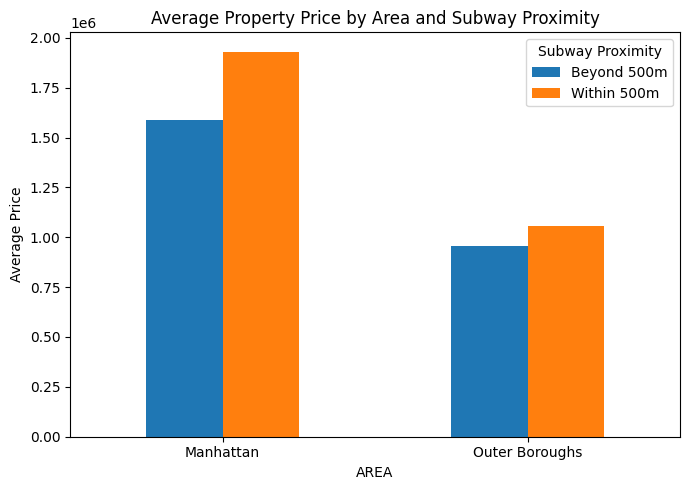

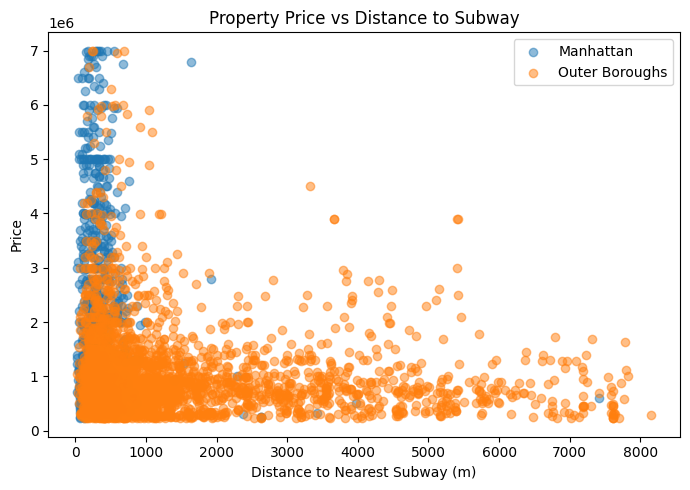

In [ ]:
# ------------------------------------------------------------------
# Compute distance to nearest subway station (vectorized haversine)
# ------------------------------------------------------------------

def haversine_distance_matrix(housing_df, subway_df):
    # Compute distance (in meters) from each property to every subway station, then return the minimum distance per property.
    # Earth's radius in meters
    R = 6371000

    # Extract coordinates and convert to radians
    housing_coords = np.radians(housing_df[['LATITUDE', 'LONGITUDE']].to_numpy())
    subway_coords  = np.radians(subway_df[['GTFS_LATITUDE', 'GTFS_LONGITUDE']].to_numpy())

    lat1 = housing_coords[:, 0][:, None]
    lon1 = housing_coords[:, 1][:, None]
    lat2 = subway_coords[:, 0][None, :]
    lon2 = subway_coords[:, 1][None, :]

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distances = R * c
    min_distances = distances.min(axis=1)  # nearest station per property

    return min_distances

# Compute distance to nearest subway station (in meters)
ny_housing_sub = ny_housing.copy()
ny_housing_sub['Dist_to_Subway'] = haversine_distance_matrix(ny_housing_sub, subway)

# Flag properties within 500 meters of a subway station
ny_housing_sub['Within_500M'] = ny_housing_sub['Dist_to_Subway'] <= 500

# ------------------------------------------------------------------
# Borough-level summary
# ------------------------------------------------------------------
borough_summary = (ny_housing_sub.dropna(subset=['BOROUGH']).groupby('BOROUGH')
    .agg(AVG_PRICE=('PRICE', 'mean'), AVG_DISTANCE_M=('Dist_to_Subway', 'mean'), PROPERTY_WITHIN_500M_PCT=('Within_500M', lambda x: 100 * x.mean()))
    .sort_values('AVG_PRICE', ascending=False))
print("\nSummary by Borough (Price vs Subway Proximity):")
print(borough_summary.round(2))

# ------------------------------------------------------------------
# Outer boroughs vs. Manhattan comparison
# ------------------------------------------------------------------
ny_housing_sub['AREA'] = np.where(ny_housing_sub['BOROUGH'] == 'Manhattan', 'Manhattan', 'Outer Boroughs')

area_summary = (ny_housing_sub.dropna(subset=['AREA']).groupby('AREA').agg(AVG_PRICE=('PRICE', 'mean'),AVG_DISTANCE_M=('Dist_to_Subway', 'mean'), PROPERTY_WITHIN_500M_PCT=('Within_500M', lambda x: 100 * x.mean())))

print("\nOuter Boroughs vs Manhattan (Subway Proximity & Prices):")
print(area_summary.round(2))

# ------------------------------------------------------------------
# Correlation: Price vs Subway Within_500M
# ------------------------------------------------------------------
print("\nCorrelation (overall) – PRICE vs Within_500M:")
print(ny_housing_sub[['PRICE', 'Within_500M']].corr().loc['PRICE', 'Within_500M'])


# Aggregate average prices by AREA and Within_500M
area_subway_price = ny_housing_sub.groupby(['AREA', 'Within_500M'])['PRICE'].mean().unstack()

# Plot
area_subway_price.plot(kind='bar', figsize=(7,5))
plt.ylabel('Average Price')
plt.title('Average Property Price by Area and Subway Proximity')
plt.xticks(rotation=0)
plt.legend(['Beyond 500m', 'Within 500m'], title='Subway Proximity')
plt.tight_layout()
plt.show()


# Scatter plot
plt.figure(figsize=(7,5))
for area, color in zip(['Manhattan', 'Outer Boroughs'], ['blue', 'green']):
    subset = ny_housing_sub[ny_housing_sub['AREA'] == area]
    plt.scatter(subset['Dist_to_Subway'], subset['PRICE'], alpha=0.5, label=area)

plt.xlabel('Distance to Nearest Subway (m)')
plt.ylabel('Price')
plt.title('Property Price vs Distance to Subway')
plt.legend()
plt.tight_layout()
plt.show()

**Hypothesis 2: Properties within 500 meters of subway stations command a price
premium compared to properties further away**

Hypothesis 2 Regression Results
                            OLS Regression Results                            
Dep. Variable:              log_PRICE   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     348.8
Date:                Tue, 16 Dec 2025   Prob (F-statistic):          6.29e-247
Time:                        22:44:44   Log-Likelihood:                -2847.4
No. Observations:                3010   AIC:                             5705.
Df Residuals:                    3005   BIC:                             5735.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           

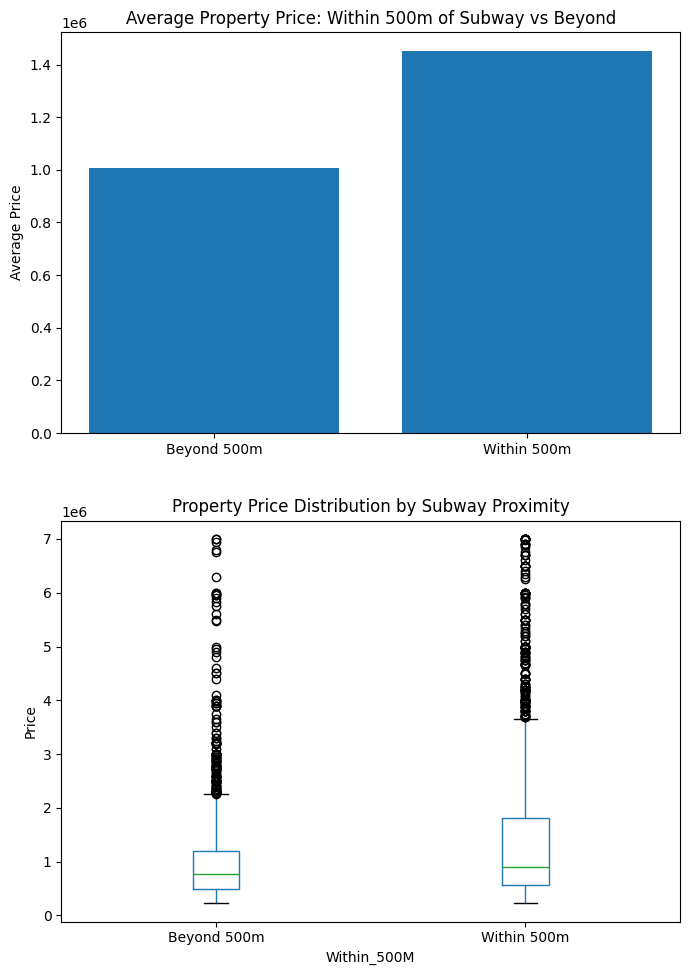

In [ ]:
# PRICE vs Subway Stations within 500 meters
# ------------------------------------------------------------------
# Prepare dataframe for H2 regression
# ------------------------------------------------------------------
eps = 1.0
ny_housing_sub['log_PRICE'] = np.log(ny_housing_sub['PRICE'] + eps)

# Convert boolean 'Within_500M' to integer (0 or 1)
ny_housing_sub['Within_500M'] = ny_housing_sub['Within_500M'].astype(float)

# Design matrix: features + Within_500M (main variable for H2)
X = ny_housing_sub[['BEDS', 'BATH', 'PROPERTYSQFT', 'Within_500M']].astype(float)
y = ny_housing_sub['log_PRICE']

# ------------------------------------------------------------------
# Train/test split and run OLS regression
# ------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit OLS regression
X_train_sm = sm.add_constant(X_train)
ols_h2 = sm.OLS(y_train, X_train_sm).fit()

print("Hypothesis 2 Regression Results")
print(ols_h2.summary())

# ------------------------------------------------------------------
# Predict on test set and report RMSE
# ------------------------------------------------------------------
X_test_sm = sm.add_constant(X_test)
y_pred_log = ols_h2.predict(X_test_sm)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"\nTest RMSE (log-price): {rmse_log:.4f}")

# Back-transform to price units
y_test_price = np.exp(y_test) - eps
y_pred_price = np.exp(y_pred_log) - eps
rmse_price = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
print(f"Test RMSE (price units, approx): {rmse_price:.2f}")

# ------------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------------
coef_within = ols_h2.params['Within_500M']
print(f"\nEstimated log-price effect of being within 500m: {coef_within:.4f}")
print(f"Approximate % price premium: {np.exp(coef_within) - 1:.2%}")

# Computing average price by Within_500M
fig, axes = plt.subplots(2, 1, figsize=(7,10))  # 2 rows, 1 column

# Plot 1: Bar chart
avg_price_subway = ny_housing_sub.groupby('Within_500M')['PRICE'].mean()
axes[0].bar(['Beyond 500m','Within 500m'], avg_price_subway.values)
axes[0].set_ylabel('Average Price')
axes[0].set_title('Average Property Price: Within 500m of Subway vs Beyond')

# Plot 2: Box plot
ny_housing_sub.boxplot(column='PRICE', by='Within_500M', grid=False, ax=axes[1])
axes[1].set_xticklabels(['Beyond 500m','Within 500m'])
axes[1].set_ylabel('Price')
axes[1].set_title('Property Price Distribution by Subway Proximity')

plt.suptitle('')
plt.tight_layout(h_pad=3)
plt.show()

**Research Question 3: What is the relationship between neighborhood-level crime rates and property prices?**


Summary by Borough (Price vs Crime_Count):
                AVG_PRICE  AVG_CRIME_COUNT
BOROUGH                                   
Manhattan      1881227.97         17324.38
Brooklyn       1260036.98          7847.64
Staten Island   890533.95          1622.24
Queens          847100.00          5065.62
The Bronx       809088.81          9103.47

Outer Boroughs vs Manhattan (Crime_Count & Prices):
                 AVG_PRICE  AVG_CRIME_COUNT
AREA                                       
Manhattan       1881227.97         17324.38
Outer Boroughs   994939.05          6105.18

Correlation (overall) – PRICE vs Crime_Count:
                   PRICE  Crime_Count_log
PRICE            1.00000          0.24451
Crime_Count_log  0.24451          1.00000

Correlation between PRICE and Crime_Count by Borough:
               Corr_PRICE_CrimeCount
BOROUGH                             
Brooklyn                       0.157
Manhattan                      0.115
Queens                        -0.117
Staten Island

/tmp/ipython-input-1561790679.py:58: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



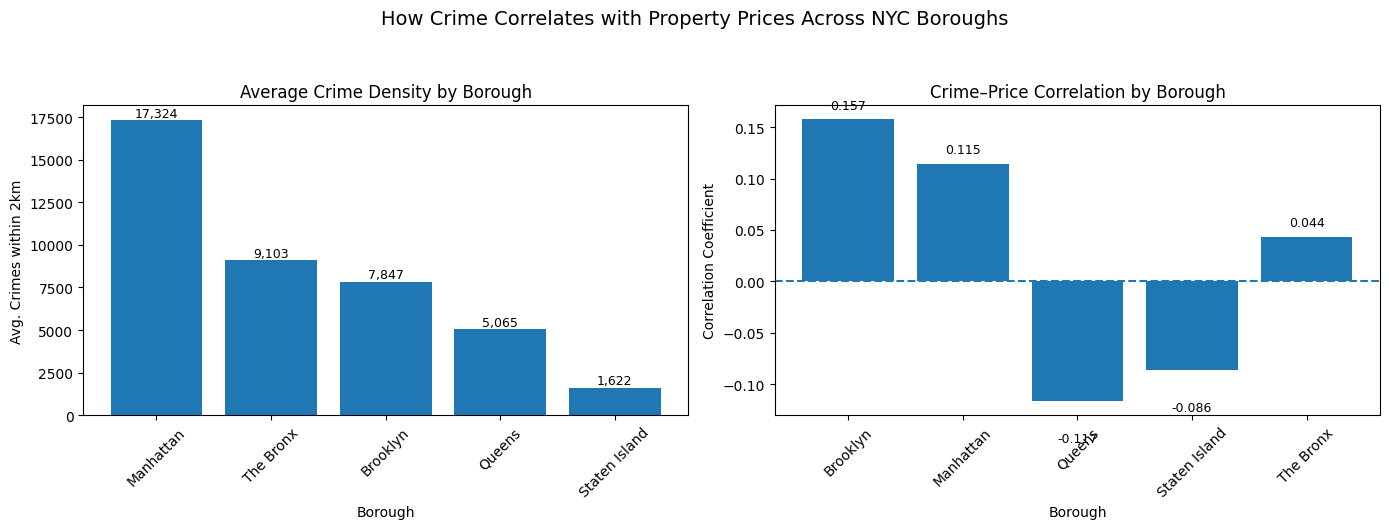

In [ ]:
# import numpy as np
# from sklearn.neighbors import BallTree

# ------------------------------------------------------------------
# Compute distance to crimes locations within 2 KMs (haversine distance using BallTree)
# ------------------------------------------------------------------
def crime_count_balltree(housing_df, crime_df, radius_m=2000):
    R = 6371000  # earth radius in meters

    # Build BallTree on crime coordinates (in radians)
    crime_coords_rad = np.radians(crime_df[['LATITUDE', 'LONGITUDE']].to_numpy())
    tree = BallTree(crime_coords_rad, metric='haversine')

    # Housing coordinates in radians
    housing_coords_rad = np.radians(housing_df[['LATITUDE', 'LONGITUDE']].to_numpy())

    # Our Radius criteria (2KMs) in radians for haversine metric
    radius_rad = radius_m / R

    # Query all properties at once: returns list of index arrays
    ind_array = tree.query_radius(housing_coords_rad, r=radius_rad)

    # Count crimes within radius for each property
    crime_counts = np.array([len(idx) for idx in ind_array], dtype=int)
    return crime_counts

ny_housing_crime = ny_housing.copy()
ny_housing_crime['Crime_Count'] = crime_count_balltree(ny_housing_crime, crime, radius_m=2000)

# split crime count in 4 quartiles and label as crime level
ny_housing_crime['Crime_Level'] = pd.qcut(ny_housing_crime['Crime_Count'], q=4, labels=['Low Crime', 'Moderate', 'High', 'Very High'])

# ------------------------------------------------------------------
# Borough-level summary
# ------------------------------------------------------------------
borough_summary = (ny_housing_crime.groupby('BOROUGH').agg(AVG_PRICE=('PRICE', 'mean'), AVG_CRIME_COUNT=('Crime_Count', 'mean')).sort_values('AVG_PRICE', ascending=False))
print("\nSummary by Borough (Price vs Crime_Count):")
print(borough_summary.round(2))

# ------------------------------------------------------------------
# Outer boroughs vs. Manhattan comparison
# ------------------------------------------------------------------
ny_housing_crime['AREA'] = np.where(ny_housing_crime['BOROUGH'] == 'Manhattan', 'Manhattan', 'Outer Boroughs')
area_summary = (ny_housing_crime.groupby('AREA').agg(AVG_PRICE=('PRICE', 'mean'), AVG_CRIME_COUNT=('Crime_Count', 'mean')))
print("\nOuter Boroughs vs Manhattan (Crime_Count & Prices):")
print(area_summary.round(2))

# ------------------------------------------------------------------
# Correlation: Price vs Crime_Count
# ------------------------------------------------------------------
print("\nCorrelation (overall) – PRICE vs Crime_Count:")
ny_housing_crime['Crime_Count_log'] = np.log1p(ny_housing_crime['Crime_Count'])
print(ny_housing_crime[['PRICE', 'Crime_Count_log']].corr())

# ------------------------------------------------------------------
# Correlation: Price vs Crime_Count (by Borough)
# ------------------------------------------------------------------
borough_corr = (ny_housing_crime.groupby('BOROUGH').apply(lambda g: g[['PRICE', 'Crime_Count']].corr().loc['PRICE', 'Crime_Count']).to_frame(name='Corr_PRICE_CrimeCount'))

print("\nCorrelation between PRICE and Crime_Count by Borough:")
print(borough_corr.round(3))


# Average crime density by borough
avg_crime_borough = (
    ny_housing_crime
    .groupby('BOROUGH')['Crime_Count']
    .mean()
    .sort_values(ascending=False)
)

# Crime–price correlation by borough (NO FutureWarning)
borough_corr = (
    ny_housing_crime
    .groupby('BOROUGH')[['PRICE', 'Crime_Count']]
    .corr()
    .loc[:, 'PRICE']
    .xs('Crime_Count', level=1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Average Crime Density
axes[0].bar(avg_crime_borough.index, avg_crime_borough.values)
axes[0].set_title('Average Crime Density by Borough')
axes[0].set_ylabel('Avg. Crimes within 2km')
axes[0].set_xlabel('Borough')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(avg_crime_borough.values):
    axes[0].text(i, v + 200, f'{int(v):,}', ha='center', fontsize=9)

# right: Crime–Price Correlation
axes[1].bar(borough_corr.index, borough_corr.values)
axes[1].axhline(0, linestyle='--')
axes[1].set_title('Crime–Price Correlation by Borough')
axes[1].set_ylabel('Correlation Coefficient')
axes[1].set_xlabel('Borough')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(borough_corr.values):
    axes[1].text(
        i, v + (0.01 if v >= 0 else -0.04),
        f'{v:.3f}', ha='center', fontsize=9
    )

fig.suptitle(
    'How Crime Correlates with Property Prices Across NYC Boroughs',
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()

**Hypothesis 3: After adjusting for property attributes, locations with higher crime rates are associated with lower housing prices**

Crime Impact Regression Results
                            OLS Regression Results                            
Dep. Variable:              log_PRICE   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     379.8
Date:                Tue, 16 Dec 2025   Prob (F-statistic):          5.26e-265
Time:                        22:44:47   Log-Likelihood:                -2805.7
No. Observations:                3010   AIC:                             5621.
Df Residuals:                    3005   BIC:                             5651.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const     

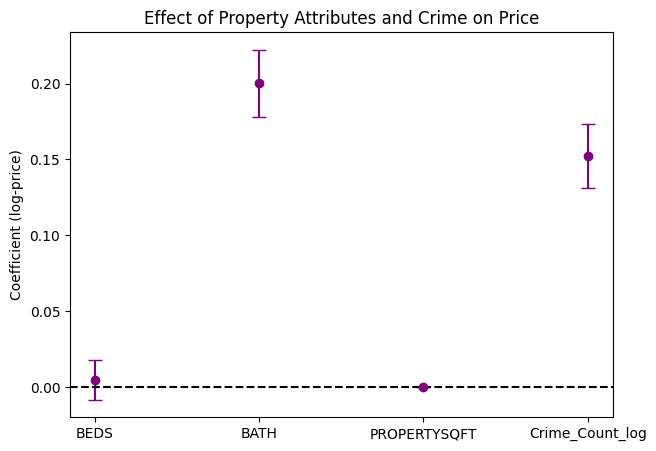

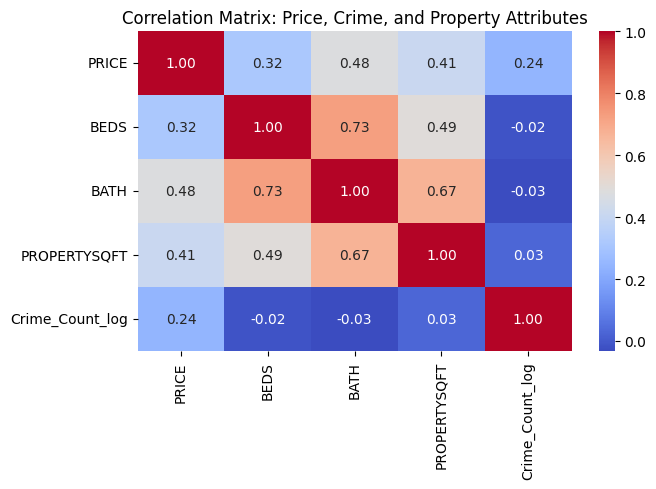

In [ ]:
# ------------------------------------------------------------------
# Prepare dataframe for Crime-Price regression
# ------------------------------------------------------------------
eps = 1.0
ny_housing_crime['log_PRICE'] = np.log(ny_housing_crime['PRICE'] + eps)

# Use Crime_Count as continuous variable (log-transformed)
ny_housing_crime['Crime_Count_log'] = np.log1p(ny_housing_crime['Crime_Count'])

# Defining Independent variables include Crime_Count_log and Dependent variable
X_cr = ny_housing_crime[['BEDS', 'BATH', 'PROPERTYSQFT', 'Crime_Count_log']].astype(float)
y_cr = ny_housing_crime['log_PRICE']

# ------------------------------------------------------------------
# Train/test split and run OLS regression
# ------------------------------------------------------------------
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cr, y_cr, test_size=0.2, random_state=42)

# Fit OLS regression
Xc_train_sm = sm.add_constant(Xc_train)
ols_cr = sm.OLS(yc_train, Xc_train_sm).fit()

print("Crime Impact Regression Results")
print(ols_cr.summary())

# ------------------------------------------------------------------
# Predict on test set and compute RMSE
# ------------------------------------------------------------------
Xc_test_sm = sm.add_constant(Xc_test)
yc_pred_log = ols_cr.predict(Xc_test_sm)

rmse_cr_log = np.sqrt(mean_squared_error(yc_test, yc_pred_log))
print(f"\nTest RMSE (log-price): {rmse_cr_log:.4f}")

# Back-transform to price units
yc_test_price = np.exp(yc_test) - eps
yc_pred_price = np.exp(yc_pred_log) - eps
rmse_cr_price = np.sqrt(mean_squared_error(yc_test_price, yc_pred_price))
print(f"Test RMSE (price units, approx): {rmse_cr_price:.2f}")

# ------------------------------------------------------------------
# Interpretation of Crime Effect
# ------------------------------------------------------------------
coef_crime = ols_cr.params['Crime_Count_log']
print(f"\nEstimated log-price effect of crime (per +1 log crime): {coef_crime:.4f}")

# Convert to percent price impact
print(f"Approximate % change in price per +1 log crime: {np.exp(coef_crime) - 1:.2%}")

coefs = ols_cr.params[['BEDS','BATH','PROPERTYSQFT','Crime_Count_log']]
conf = ols_cr.conf_int().loc[['BEDS','BATH','PROPERTYSQFT','Crime_Count_log']]


#displays the plots
plt.figure(figsize=(7,5))
plt.errorbar(coefs.index, coefs.values,
             yerr=[coefs.values - conf[0], conf[1] - coefs.values],
             fmt='o', color='purple', capsize=5)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Coefficient (log-price)')
plt.title('Effect of Property Attributes and Crime on Price')
plt.show()


corr_vars = ['PRICE','BEDS','BATH','PROPERTYSQFT','Crime_Count_log']
plt.figure(figsize=(7,5))
sns.heatmap(ny_housing_crime[corr_vars].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix: Price, Crime, and Property Attributes')
plt.tight_layout()
plt.show()
